# Real Data Experiments of NeurIPS 2023 Paper

Reproduces Table 2 and Figure 3 of the NeurIPS 2023 paper comparing

1. `EM` - Bayesian Ridge Regression with maximisisation of the marginal $(\sigma^2, \tau^2)$ posterior via EM algorithm with half-Cauchy prior on $\tau$ (`RidgeEM(t2=False)`)
2. `CV_fix` - LOOCV Ridge regression with 100 logarithmically spaced candidates for $\lambda$ (`RidgeLOOCV(alphas=np.logspace(-10, 10, 100, base=10)`)
3. `CV_glm` - LOOCV Ridge regression with 100 candidates chosen according to the GLMNet heuristic (`RidgeLOOCV(alphas=100)`)

in terms of the $R^2$-vales they achieve on the `NEURIPS2023` problem collection.

All experiments take substantial time and are therefore not run during integration testing. The overall expected computation time using an Apple M4 Pro chip is about 2h.

## No Interaction Variables

Expected computation time on Apple M4 Pro about 20 minutes.

In [ ]:
import numpy as np
from fastridge import RidgeEM, RidgeLOOCV
from experiments import ExperimentWithPerSeriesSeeding
from problems import NEURIPS2023, NEURIPS2023_TRAIN_SIZES
from data import DATASETS

# estimator indices: 0=EM, 1=CV_fix, 2=CV_glm
estimators = [
    RidgeEM(t2=False),
    RidgeLOOCV(alphas=np.logspace(-10, 10, 100, base=10)),
    RidgeLOOCV(alphas=100),
]
est_names = ['EM', 'CV_fix', 'CV_glm']

problems_d1 = sorted(NEURIPS2023, key=lambda p: DATASETS[p.dataset]['n'])
exp_d1 = ExperimentWithPerSeriesSeeding(
    problems_d1, estimators,
    reps=100, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_d1],
    seed=123,
    est_names=est_names, verbose=True).run()
print()

In [2]:
import pandas as pd

rows_d1 = []
for i, problem in enumerate(exp_d1.problems):
    em_time  = np.nanmean(exp_d1.fitting_time_[:, i, 0, 0])
    cv_time  = (np.nanmean(exp_d1.fitting_time_[:, i, 0, 1])
               + np.nanmean(exp_d1.fitting_time_[:, i, 0, 2])) / 2
    row = {'dataset': problem.dataset, 'target': problem.target, 'd': 1}
    for j, name in enumerate(exp_d1.est_names):
        row[name] = np.nanmean(exp_d1.prediction_r2_[:, i, 0, j])
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = np.nanmean(exp_d1.number_of_features_[:, i, 0, 0])
    row['n_train']        = int(exp_d1.ns[i, 0])
    row['n:p']            = int(exp_d1.ns[i, 0]) / np.nanmean(exp_d1.number_of_features_[:, i, 0, 0])
    rows_d1.append(row)
df_d1 = pd.DataFrame(rows_d1).sort_values(['n_train', 'dataset', 'target'], ascending=[False, True, True]).round(2)
df_d1

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
22,twitter,V78,1,0.93,0.93,0.93,4.68,77.00,408275,5302.27
21,ct_slices,reference,1,0.86,0.86,0.86,3.53,379.73,37450,98.62
20,blog,V281,1,0.35,0.35,0.35,3.77,275.77,36677,133.00
19,tomshw,V97,1,0.96,0.96,0.96,3.82,96.00,19725,205.47
17,naval_propulsion,GT_compressor_decay,1,0.84,0.84,0.84,6.73,15.00,8353,556.87
18,naval_propulsion,GT_turbine_decay,1,0.91,0.91,0.91,6.78,15.00,8353,556.87
15,parkinsons,motor_UPDRS,1,0.15,0.15,0.15,5.55,19.00,4112,216.42
16,parkinsons,total_UPDRS,1,0.17,0.17,0.17,5.65,19.00,4112,216.42
14,abalone,Rings,1,0.53,0.53,0.53,8.48,9.00,2923,324.78
13,crime,ViolentCrimesPerPop,1,0.66,0.66,0.66,2.39,99.00,1395,14.09


## 2nd Order Terms

Expected computation time on Apple M4 Pro: about 60 minutes.

In [ ]:
from problems import NEURIPS2023_D2

problems_d2 = sorted(NEURIPS2023_D2, key=lambda p: DATASETS[p.dataset]['n'])
exp_d2 = ExperimentWithPerSeriesSeeding(
    problems_d2, estimators,
    reps=100, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_d2],
    seed=123,
    est_names=est_names, verbose=True).run()
print()

In [4]:
rows_d2 = []
for i, problem in enumerate(exp_d2.problems):
    em_time  = np.nanmean(exp_d2.fitting_time_[:, i, 0, 0])
    cv_time  = (np.nanmean(exp_d2.fitting_time_[:, i, 0, 1])
               + np.nanmean(exp_d2.fitting_time_[:, i, 0, 2])) / 2
    row = {'dataset': problem.dataset, 'target': problem.target, 'd': 2}
    for j, name in enumerate(exp_d2.est_names):
        row[name] = np.nanmean(exp_d2.prediction_r2_[:, i, 0, j])
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = np.nanmean(exp_d2.number_of_features_[:, i, 0, 0])
    row['n_train']        = int(exp_d2.ns[i, 0])
    row['n:p']            = int(exp_d2.ns[i, 0]) / np.nanmean(exp_d2.number_of_features_[:, i, 0, 0])
    rows_d2.append(row)
df_d2 = pd.DataFrame(rows_d2).sort_values(['n_train', 'dataset', 'target'], ascending=[False, True, True]).round(2)
df_d2

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
21,twitter,V78,2,0.93,0.93,0.93,5.04,86.00,408275,4747.38
20,ct_slices,reference,2,0.92,0.92,0.92,2.84,929.73,37450,40.28
19,blog,V281,2,0.43,0.43,0.43,2.79,890.66,36677,41.18
18,tomshw,V97,2,0.90,0.96,0.96,1.98,1775.00,19725,11.11
16,naval_propulsion,GT_compressor_decay,2,1.00,1.00,1.00,3.30,149.00,8353,56.06
17,naval_propulsion,GT_turbine_decay,2,1.00,1.00,1.00,3.30,149.00,8353,56.06
14,parkinsons,motor_UPDRS,2,0.24,0.18,0.20,2.89,209.00,4112,19.67
15,parkinsons,total_UPDRS,2,0.24,0.21,0.22,2.88,209.00,4112,19.67
13,abalone,Rings,2,0.34,0.34,0.34,5.23,53.00,2923,55.15
12,crime,ViolentCrimesPerPop,2,0.67,-0.76,0.66,1.22,5049.00,1395,0.28


## 3rd Order Terms

Expected computation time on Apple M4 Pro: about 30 minutes.

In [ ]:
from problems import NEURIPS2023_D3

problems_d3 = sorted(NEURIPS2023_D3, key=lambda p: DATASETS[p.dataset]['n'])
exp_d3 = ExperimentWithPerSeriesSeeding(
    problems_d3, estimators,
    reps=100, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_d3],
    seed=123,
    est_names=est_names, verbose=True).run()
print()

In [6]:
rows_d3 = []
for i, problem in enumerate(exp_d3.problems):
    em_time  = np.nanmean(exp_d3.fitting_time_[:, i, 0, 0])
    cv_time  = (np.nanmean(exp_d3.fitting_time_[:, i, 0, 1])
               + np.nanmean(exp_d3.fitting_time_[:, i, 0, 2])) / 2
    row = {'dataset': problem.dataset, 'target': problem.target, 'd': 3}
    for j, name in enumerate(exp_d3.est_names):
        row[name] = np.nanmean(exp_d3.prediction_r2_[:, i, 0, j])
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = np.nanmean(exp_d3.number_of_features_[:, i, 0, 0])
    row['n_train']        = int(exp_d3.ns[i, 0])
    row['n:p']            = int(exp_d3.ns[i, 0]) / np.nanmean(exp_d3.number_of_features_[:, i, 0, 0])
    rows_d3.append(row)
df_d3 = pd.DataFrame(rows_d3).sort_values(['n_train', 'dataset', 'target'], ascending=[False, True, True]).round(2)
df_d3

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
16,naval_propulsion,GT_compressor_decay,3,1.00,1.00,1.00,2.58,963.00,8353,8.67
15,naval_propulsion,GT_turbine_decay,3,1.00,1.00,1.00,2.57,963.00,8353,8.67
14,parkinsons,motor_UPDRS,3,-0.25,0.27,0.27,1.86,1539.00,4112,2.67
13,parkinsons,total_UPDRS,3,-0.50,0.23,0.23,1.87,1539.00,4112,2.67
12,abalone,Rings,3,-0.52,-0.53,-0.53,2.97,209.00,2923,13.99
11,crime,ViolentCrimesPerPop,3,0.66,-0.25,0.57,1.03,25076.00,1395,0.06
10,airfoil,scaled-sound-pressure,3,0.73,0.73,0.73,5.46,55.00,1052,19.13
9,concrete,Concrete compressive strength,3,0.85,0.85,0.86,3.21,164.00,721,4.40
8,student,G3,3,0.24,-0.43,-0.41,0.92,10530.03,454,0.04
7,forest,area,3,-0.03,-316.60,-0.85,0.11,1964.96,361,0.18


## Summary

In [7]:
df_all = (pd.concat([df_d1, df_d2, df_d3])                                                                                                                                                                                                                                                                  
            .sort_values(['n_train', 'dataset', 'target', 'd'],                                                                                                                                                                                                                                             
                        ascending=[False, True, True, True])                                                                                                                                                                                                                                               
            .round(2)                                                                                                                                                                                                                                                                                       
            .reset_index(drop=True))                                                                                                                                                                                                                                                                        
df_all   

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,1,0.93,0.93,0.93,4.68,77.00,408275,5302.27
1,twitter,V78,2,0.93,0.93,0.93,5.04,86.00,408275,4747.38
2,ct_slices,reference,1,0.86,0.86,0.86,3.53,379.73,37450,98.62
3,ct_slices,reference,2,0.92,0.92,0.92,2.84,929.73,37450,40.28
4,blog,V281,1,0.35,0.35,0.35,3.77,275.77,36677,133.00
...,...,...,...,...,...,...,...,...,...,...
57,automobile,price,2,0.90,-3575.53,0.89,1.26,1006.81,111,0.11
58,automobile,price,3,0.89,-2569.30,0.83,0.64,12076.68,111,0.01
59,eye,y,1,0.50,0.22,0.45,1.26,200.00,84,0.42
60,eye,y,2,0.20,0.20,0.20,1.07,20300.00,84,0.00


In [8]:
n_train_col = df_all.groupby(['dataset', 'target'])['n_train'].first()
metric_cols = ['EM', 'CV_fix', 'CV_glm', 'Speed Up Ratio', 'p']                
df_wide = df_all.pivot_table(                                                                                                                                                                                                                                                                               
    index=['dataset', 'target'],                                                                                                                                                                                                                                                                            
    columns='d',                                                                                                                                                                                                                                                                                            
    values=metric_cols,                                                                                                                                                                                                                                                                                     
    sort=False                                                                                                                                                                                                                                                                                              
)                                      
# Make degree the outer column level
df_wide = df_wide.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)
df_wide.columns.names = ['d', 'metric']                                        
                                                                                
# Prepend n_train and sort                                                                                                                                                                                                                                                                                  
df_wide.insert(0, 'n_train', n_train_col)                                                                                                                                                                                                                                                                   
df_wide = df_wide.sort_values('n_train', ascending=False).round(2)
df_wide.to_csv('../output/paper2023_table2.csv', index=False)                                                                                                                                                                                                                                     
df_wide  

d                                              n_train     1                \
metric                                                    EM CV_fix CV_glm   
dataset          target                                                      
twitter          V78                            408275  0.93   0.93   0.93   
ct_slices        reference                       37450  0.86   0.86   0.86   
blog             V281                            36677  0.35   0.35   0.35   
tomshw           V97                             19725  0.96   0.96   0.96   
naval_propulsion GT_compressor_decay              8353  0.84   0.84   0.84   
                 GT_turbine_decay                 8353  0.91   0.91   0.91   
parkinsons       motor_UPDRS                      4112  0.15   0.15   0.15   
                 total_UPDRS                      4112  0.17   0.17   0.17   
abalone          Rings                            2923  0.53   0.53   0.53   
crime            ViolentCrimesPerPop              1395  0.66   0.66   0.66   
airfoil          scaled-sound-pressure            1052  0.51   0.51   0.51   
concrete         Concrete compressive strength     721  0.61   0.61   0.61   
student          G3                                454  0.27   0.27   0.27   
forest           area                              361 -0.02  -0.02  -0.05   
boston           medv                              354  0.71   0.71   0.71   
facebook         Total Interactions                349  0.90   0.89   0.90   
diabetes         target                            309  0.49   0.49   0.49   
real_estate      Y house price of unit area        289  0.56   0.56   0.56   
autompg          mpg                               274  0.81   0.81   0.81   
yacht            Residuary_resistance              215  0.97   0.97   0.97   
automobile       price                             111  0.91   0.90   0.90   
eye              y                                  84  0.50   0.22   0.45   
ribo             y                                  49  0.64   0.64   0.64   

d                                                                          2  \
metric                                         Speed Up Ratio        p    EM   
dataset          target                                                        
twitter          V78                                     4.68    77.00  0.93   
ct_slices        reference                               3.53   379.73  0.92   
blog             V281                                    3.77   275.77  0.43   
tomshw           V97                                     3.82    96.00  0.90   
naval_propulsion GT_compressor_decay                     6.73    15.00  1.00   
                 GT_turbine_decay                        6.78    15.00  1.00   
parkinsons       motor_UPDRS                             5.55    19.00  0.24   
                 total_UPDRS                             5.65    19.00  0.24   
abalone          Rings                                   8.48     9.00  0.34   
crime            ViolentCrimesPerPop                     2.39    99.00  0.67   
airfoil          scaled-sound-pressure                   9.85     5.00  0.63   
concrete         Concrete compressive strength           8.27     8.00  0.78   
student          G3                                      5.65    39.00  0.26   
forest           area                                    0.35    26.43 -0.02   
boston           medv                                    6.81    13.00  0.85   
facebook         Total Interactions                      6.82    17.00 -6.57   
diabetes         target                                  7.00    10.00  0.46   
real_estate      Y house price of unit area              8.70     6.00  0.65   
autompg          mpg                                     8.23     7.00  0.86   
yacht            Residuary_resistance                    8.63     6.00  0.97   
automobile       price                                   4.47    50.06  0.90   
eye              y                                 

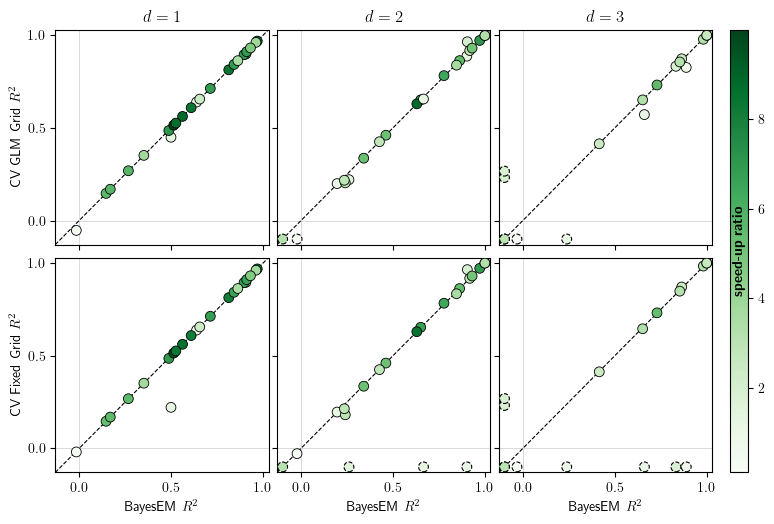

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from plotting import scatter_clipped, grid_with_colourbar

su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp_d1, exp_d2, exp_d3] for cv in [2, 1] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp_d1, exp_d2, exp_d3]):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])

fig.savefig('../output/paper2023_figure3.pdf', bbox_inches='tight')


In [10]:
df_csv = df_wide.reset_index()                                                                                                                                                                                                                                                                            
df_csv.columns = [                                                                                                                                                                                                                                                                                          
    col if isinstance(col, str) else                                                                                                                                                                                                                                                                      
    f'd{col[0]}_{col[1]}' if isinstance(col[0], int) else                                                                                                                                                                                                                                                   
    col[0]                                                                                                                                                                                                                                                                                                
    for col in df_csv.columns                                                  
]
df_csv.to_csv('../output/paper2023_table2.csv', index=False)     